In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [2]:
BASE_DIR = Path.cwd().parent

PROCESSED_DATA_PATH = (
    BASE_DIR
    / "Data"
    / "Processed"
    / "diabetic_data_processed.csv"
)

print(PROCESSED_DATA_PATH)

c:\Users\Sai\Documents\HealthSense_AI\Data\Processed\diabetic_data_processed.csv


In [3]:
df = pd.read_csv(
    PROCESSED_DATA_PATH
)

print(
    f"Rows: {df.shape[0]}"
)

print(
    f"Columns: {df.shape[1]}"
)

Rows: 101766
Columns: 50


In [6]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,max_glu_serum_available,A1Cresult_available
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,0,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,No,No,No,No,Ch,Yes,1,0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,Yes,0,0,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,No,No,No,No,Ch,Yes,0,0,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,No,No,No,No,Ch,Yes,0,0,0


In [5]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,max_glu_serum_available,A1Cresult_available
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.460881,0.052532,0.167227
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.498470,0.223099,0.373180
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,1.000000,0.000000,0.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000,1.000000,1.000000


In [4]:
df.describe(include="object")

C:\Users\Sai\AppData\Local\Temp\ipykernel_13012\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,race,gender,age,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,73,717,749,790,4,4,4,...,1,1,4,4,2,2,2,2,2,2
top,Caucasian,Female,[70-80),Unknown,428,276,250,Not Tested,Not Tested,No,...,No,No,No,No,No,No,No,No,No,Yes
freq,76099,54708,26068,49949,6862,6752,11555,96420,84748,81778,...,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363


In [7]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_values.head(20)

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
dtype: int64

In [8]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 0


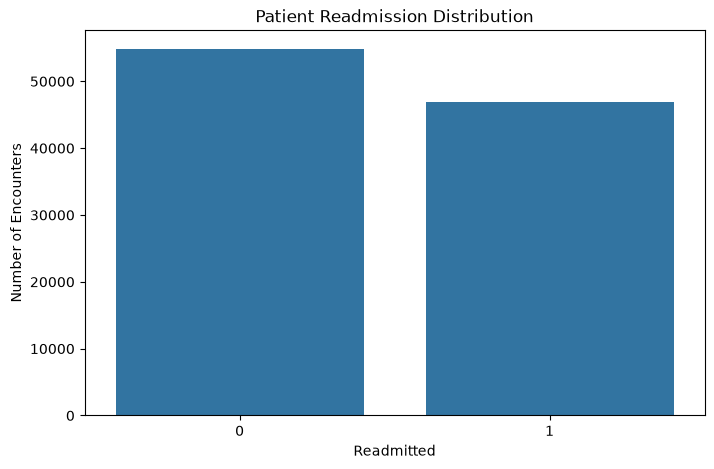

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title(
    "Patient Readmission Distribution"
)

plt.xlabel(
    "Readmitted"
)

plt.ylabel(
    "Number of Encounters"
)

plt.show()

In [10]:
readmission_rate = (
    df["readmitted"]
    .value_counts(
        normalize=True
    ) * 100
)

print(
    readmission_rate
)

readmitted
0    53.911916
1    46.088084
Name: proportion, dtype: float64


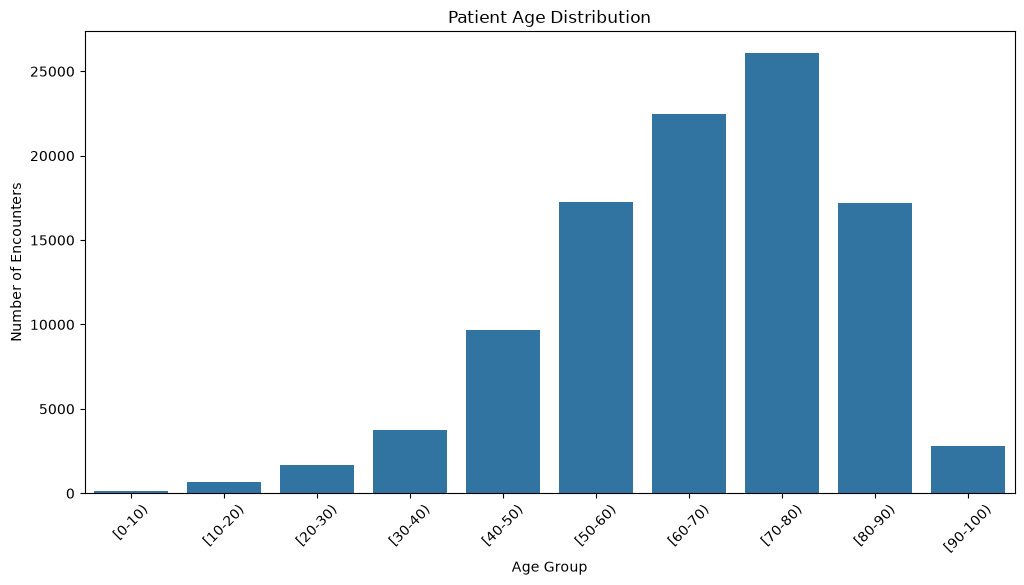

In [11]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="age",
    order=sorted(
        df["age"].unique()
    )
)

plt.title(
    "Patient Age Distribution"
)

plt.xlabel(
    "Age Group"
)

plt.ylabel(
    "Number of Encounters"
)

plt.xticks(
    rotation=45
)

plt.show()

In [12]:
age_readmission = (
    df.groupby("age")["readmitted"]
    .mean()
    .sort_values(
        ascending=False
    ) * 100
)

age_readmission

age
[80-90)     48.270047
[70-80)     48.120301
[60-70)     46.252724
[20-30)     45.021123
[40-50)     44.450181
[50-60)     43.955726
[30-40)     42.675497
[90-100)    40.028643
[10-20)     38.205499
[0-10)      18.012422
Name: readmitted, dtype: float64

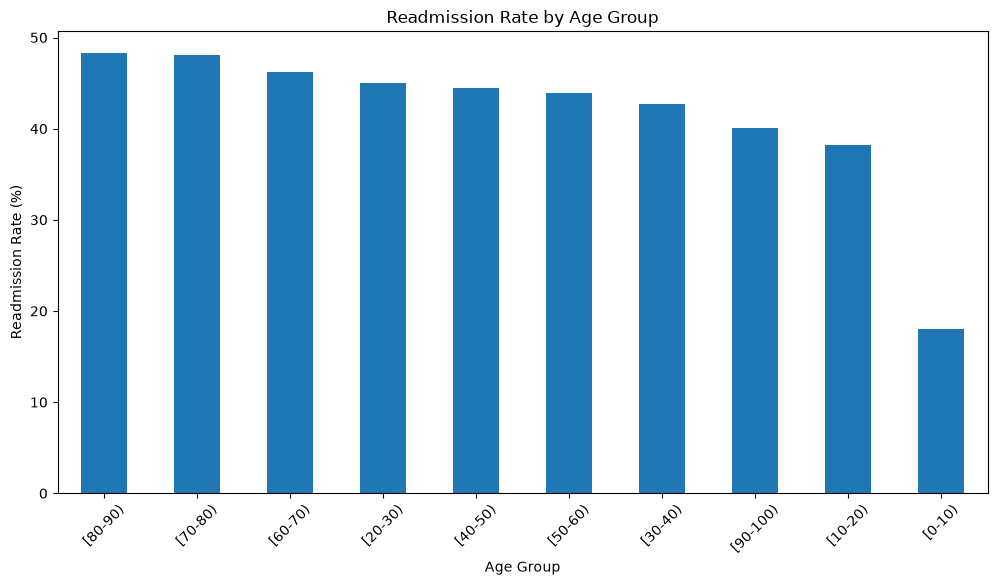

In [13]:
plt.figure(figsize=(12, 6))

age_readmission.plot(
    kind="bar"
)

plt.title(
    "Readmission Rate by Age Group"
)

plt.xlabel(
    "Age Group"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.xticks(
    rotation=45
)

plt.show()

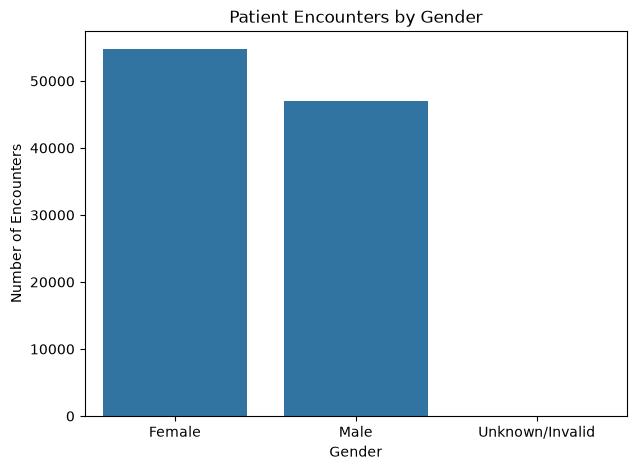

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title(
    "Patient Encounters by Gender"
)

plt.xlabel(
    "Gender"
)

plt.ylabel(
    "Number of Encounters"
)

plt.show()

In [15]:
gender_readmission = (
    df.groupby("gender")["readmitted"]
    .mean()
    .sort_values(
        ascending=False
    ) * 100
)

print(
    gender_readmission
)

gender
Female             46.921840
Male               45.121666
Unknown/Invalid     0.000000
Name: readmitted, dtype: float64


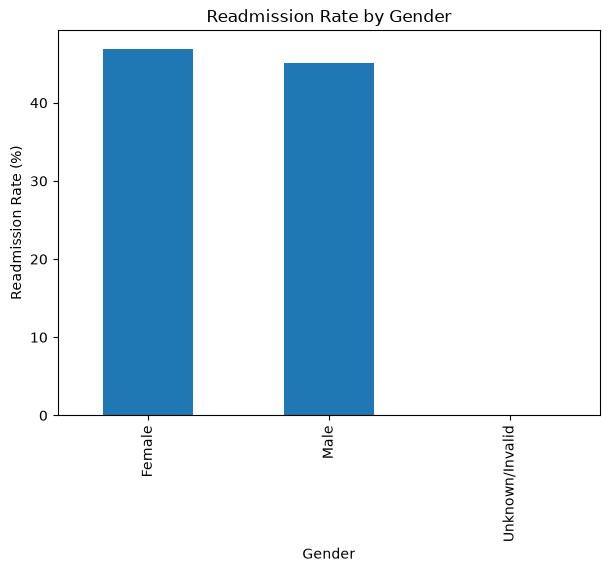

In [16]:
plt.figure(figsize=(7, 5))

gender_readmission.plot(
    kind="bar"
)

plt.title(
    "Readmission Rate by Gender"
)

plt.xlabel(
    "Gender"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

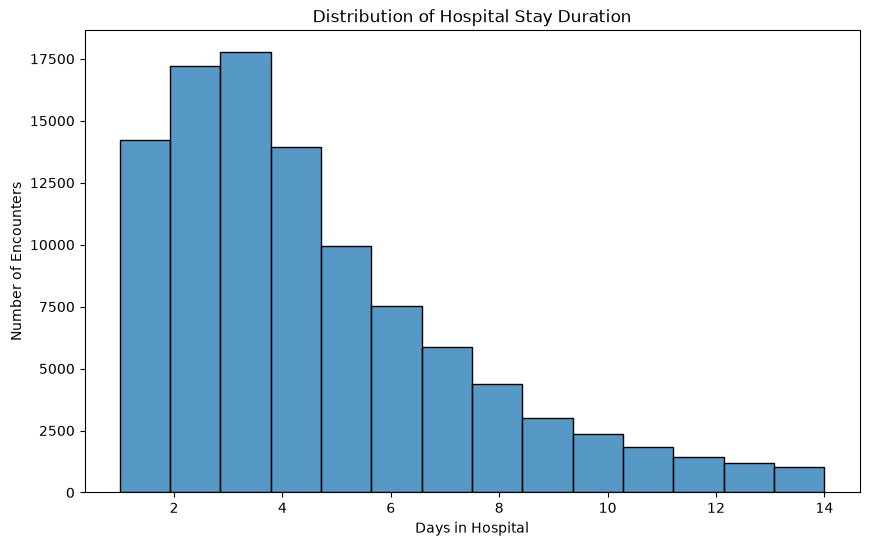

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="time_in_hospital",
    bins=14
)

plt.title(
    "Distribution of Hospital Stay Duration"
)

plt.xlabel(
    "Days in Hospital"
)

plt.ylabel(
    "Number of Encounters"
)

plt.show()

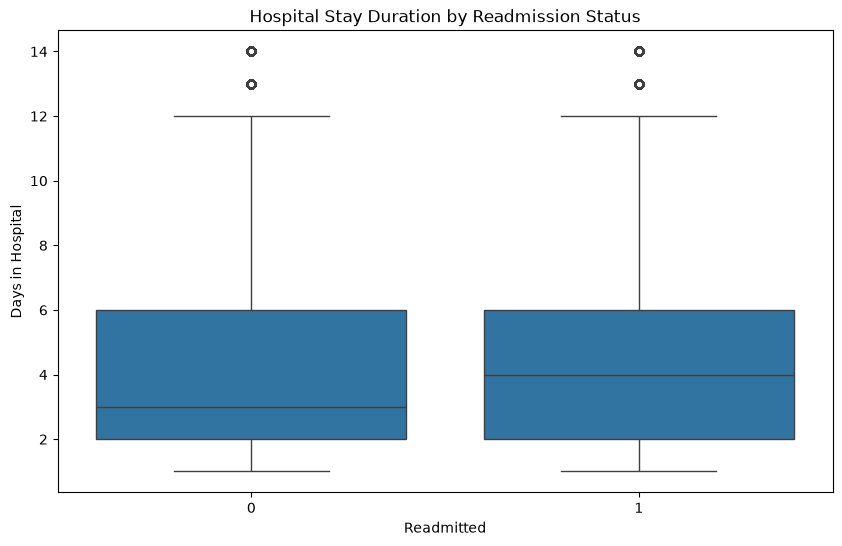

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmitted",
    y="time_in_hospital"
)

plt.title(
    "Hospital Stay Duration by Readmission Status"
)

plt.xlabel(
    "Readmitted"
)

plt.ylabel(
    "Days in Hospital"
)

plt.show()

In [19]:
utilization_columns = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

df[
    utilization_columns
].describe()

,number_inpatient,number_emergency,number_outpatient
count,101766.000000,101766.000000,101766.000000
mean,0.635566,0.197836,0.369357
std,1.262863,0.930472,1.267265
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,21.000000,76.000000,42.000000


In [20]:
inpatient_readmission = (
    df.groupby(
        "number_inpatient"
    )["readmitted"]
    .mean() * 100
)

inpatient_readmission

number_inpatient
0      38.494751
1      54.761539
2      64.935237
3      69.715626
4      74.229346
5      80.049261
6      84.166667
7      80.970149
8      90.728477
9      88.288288
10     85.245902
11    100.000000
12     88.235294
13     90.000000
14    100.000000
15    100.000000
16     66.666667
17    100.000000
18    100.000000
19    100.000000
21    100.000000
Name: readmitted, dtype: float64

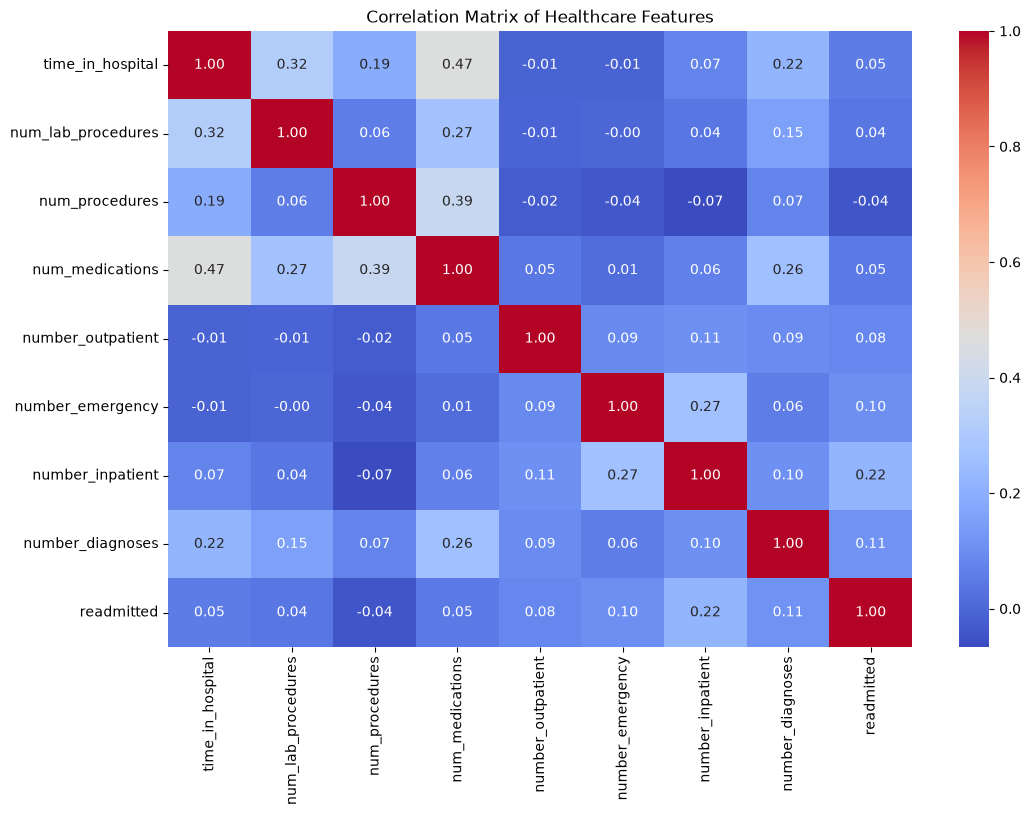

In [21]:
numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted"
]

correlation_matrix = (
    df[numeric_columns]
    .corr()
)

plt.figure(
    figsize=(12, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix of Healthcare Features"
)

plt.show()

In [22]:
inpatient_readmission = (
    df.groupby("number_inpatient")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

inpatient_readmission["readmission_rate"] = (
    inpatient_readmission["readmission_rate"] * 100
)

inpatient_readmission

,total_encounters,readmissions,readmission_rate
number_inpatient,,,
0,67630,26034,38.494751
1,19521,10690,54.761539
2,7566,4913,64.935237
3,3411,2378,69.715626
4,1622,1204,74.229346
5,812,650,80.049261
6,480,404,84.166667
7,268,217,80.970149
8,151,137,90.728477


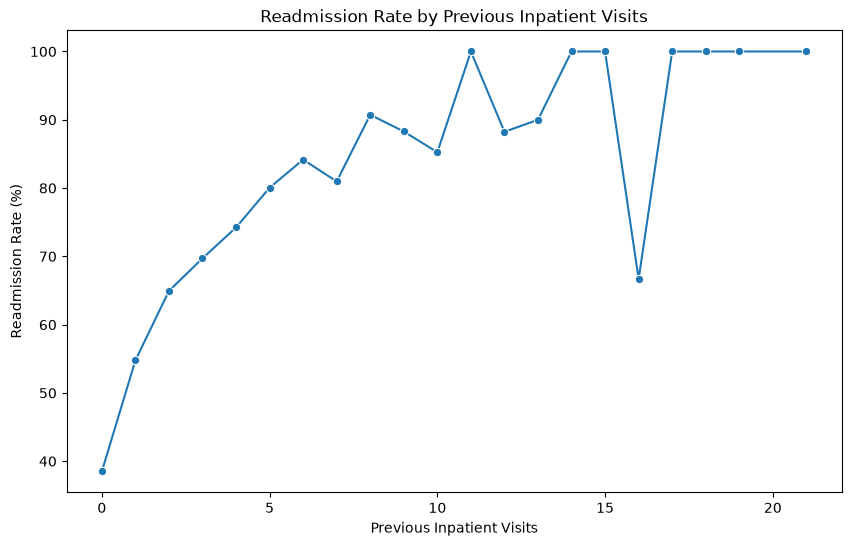

In [23]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=inpatient_readmission,
    x=inpatient_readmission.index,
    y="readmission_rate",
    marker="o"
)

plt.title(
    "Readmission Rate by Previous Inpatient Visits"
)

plt.xlabel(
    "Previous Inpatient Visits"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [24]:
emergency_readmission = (
    df.groupby("number_emergency")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

emergency_readmission["readmission_rate"] = (
    emergency_readmission["readmission_rate"] * 100
)

emergency_readmission.head(20)

,total_encounters,readmissions,readmission_rate
number_emergency,,,
0,90383,39673,43.894316
1,7677,4552,59.293995
2,2042,1370,67.091087
3,725,521,71.862069
4,374,305,81.550802
5,192,154,80.208333
6,94,79,84.042553
7,73,66,90.410959
8,50,41,82.000000


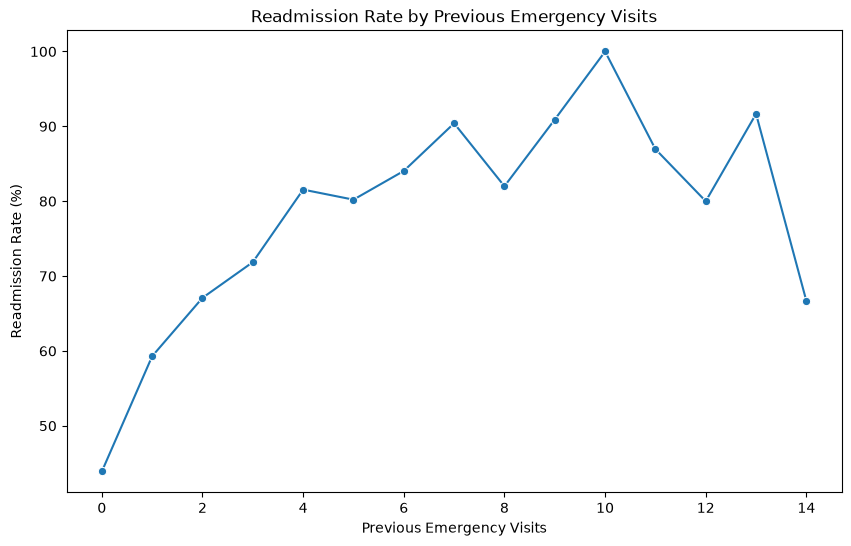

In [25]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=emergency_readmission.head(15),
    x=emergency_readmission.head(15).index,
    y="readmission_rate",
    marker="o"
)

plt.title(
    "Readmission Rate by Previous Emergency Visits"
)

plt.xlabel(
    "Previous Emergency Visits"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [26]:
outpatient_readmission = (
    df.groupby("number_outpatient")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

outpatient_readmission["readmission_rate"] = (
    outpatient_readmission["readmission_rate"] * 100
)

outpatient_readmission.head(20)

,total_encounters,readmissions,readmission_rate
number_outpatient,,,
0,85027,37115,43.650840
1,8547,4904,57.376857
2,3594,2160,60.100167
3,2042,1173,57.443683
4,1099,646,58.780710
5,533,306,57.410882
6,303,194,64.026403
7,155,107,69.032258
8,98,45,45.918367


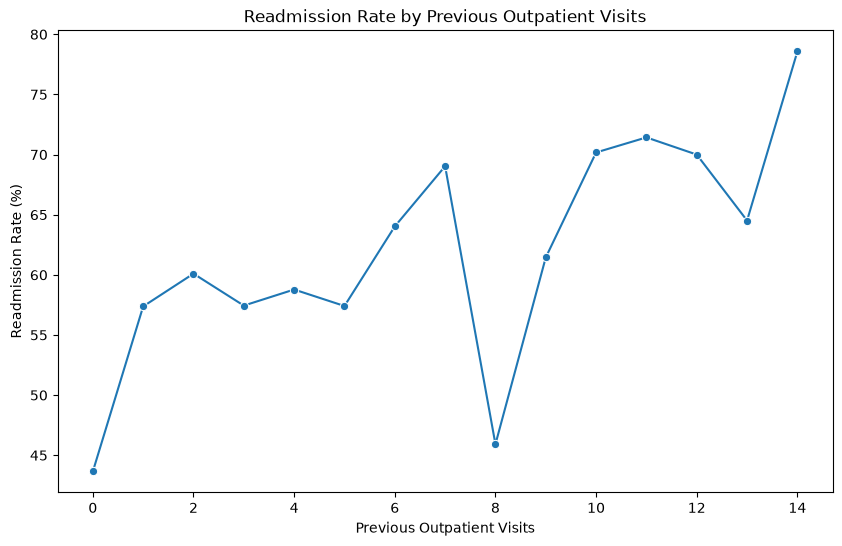

In [27]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=outpatient_readmission.head(15),
    x=outpatient_readmission.head(15).index,
    y="readmission_rate",
    marker="o"
)

plt.title(
    "Readmission Rate by Previous Outpatient Visits"
)

plt.xlabel(
    "Previous Outpatient Visits"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [28]:
medication_readmission = (
    df.groupby("num_medications")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

medication_readmission["readmission_rate"] = (
    medication_readmission["readmission_rate"] * 100
)

medication_readmission

,total_encounters,readmissions,readmission_rate
num_medications,,,
1,262,83,31.679389
2,470,145,30.851064
3,900,274,30.444444
4,1417,495,34.932957
5,2017,687,34.060486
...,...,...,...
72,3,3,100.000000
74,1,0,0.000000
75,2,0,0.000000


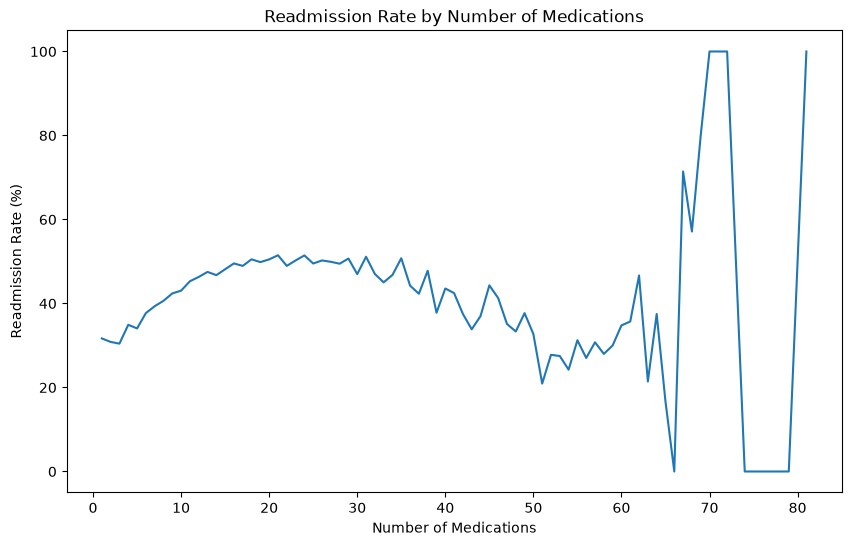

In [29]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=medication_readmission,
    x=medication_readmission.index,
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by Number of Medications"
)

plt.xlabel(
    "Number of Medications"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [30]:
diagnosis_readmission = (
    df.groupby("number_diagnoses")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

diagnosis_readmission["readmission_rate"] = (
    diagnosis_readmission["readmission_rate"] * 100
)

diagnosis_readmission

,total_encounters,readmissions,readmission_rate
number_diagnoses,,,
1,219,52,23.744292
2,1023,336,32.844575
3,2835,972,34.285714
4,5537,2063,37.258443
5,11393,4039,35.451593
6,10161,4455,43.844110
7,10393,4851,46.675647
8,10616,5052,47.588546
9,49474,25026,50.584145


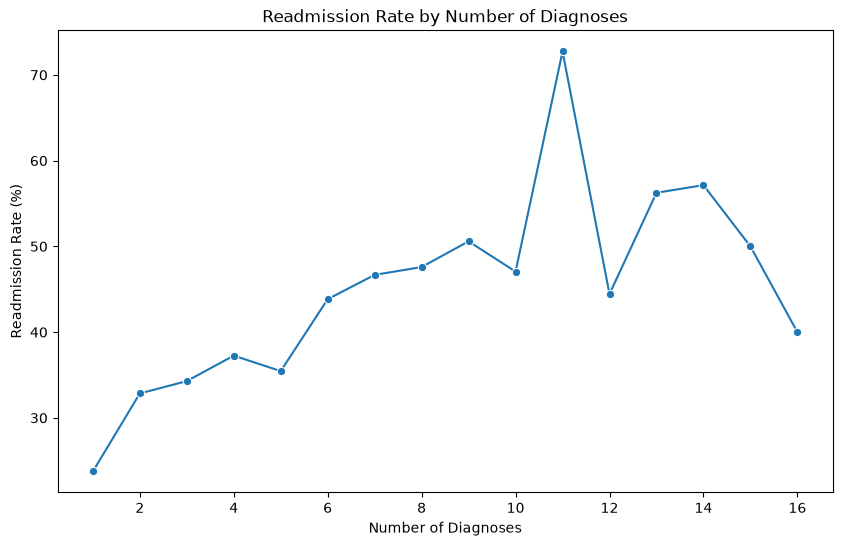

In [31]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=diagnosis_readmission,
    x=diagnosis_readmission.index,
    y="readmission_rate",
    marker="o"
)

plt.title(
    "Readmission Rate by Number of Diagnoses"
)

plt.xlabel(
    "Number of Diagnoses"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

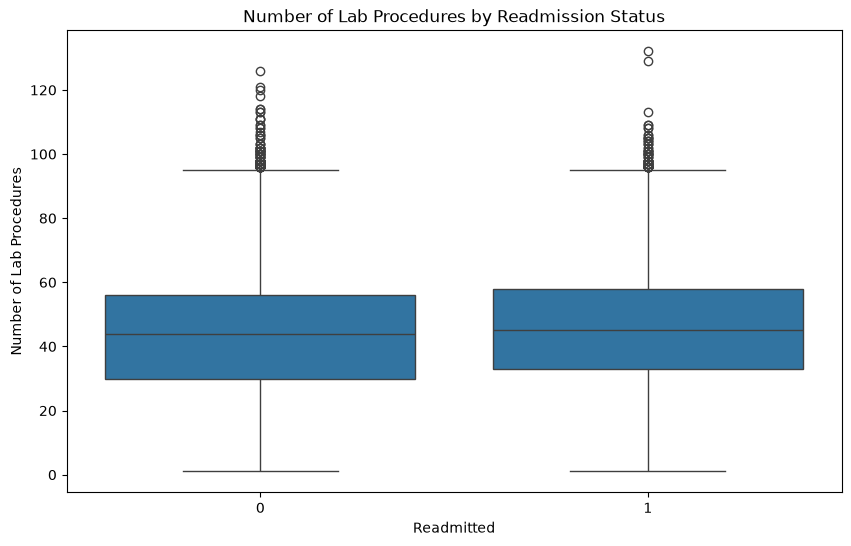

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmitted",
    y="num_lab_procedures"
)

plt.title(
    "Number of Lab Procedures by Readmission Status"
)

plt.xlabel(
    "Readmitted"
)

plt.ylabel(
    "Number of Lab Procedures"
)

plt.show()

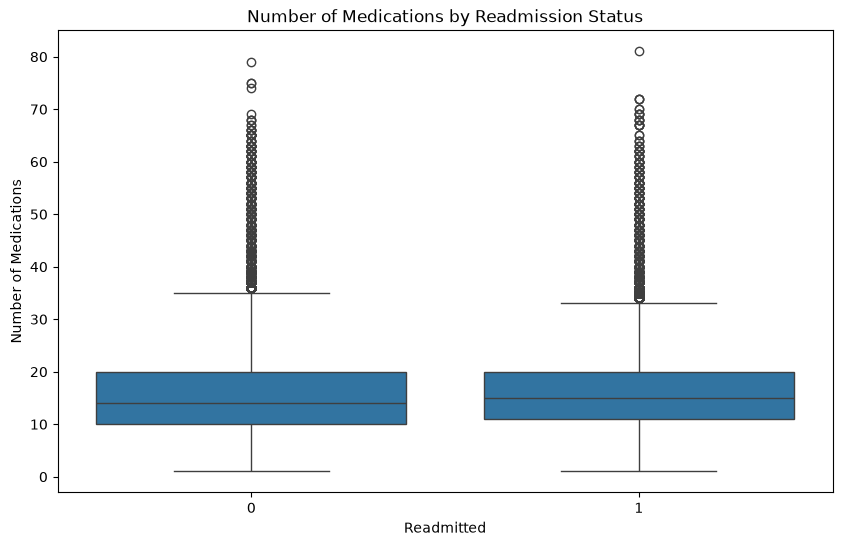

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmitted",
    y="num_medications"
)

plt.title(
    "Number of Medications by Readmission Status"
)

plt.xlabel(
    "Readmitted"
)

plt.ylabel(
    "Number of Medications"
)

plt.show()

In [34]:
diabetes_med_readmission = (
    df.groupby("diabetesMed")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

diabetes_med_readmission["readmission_rate"] = (
    diabetes_med_readmission["readmission_rate"] * 100
)

diabetes_med_readmission

,total_encounters,readmissions,readmission_rate
diabetesMed,,,
No,23403,9473,40.477717
Yes,78363,37429,47.763613


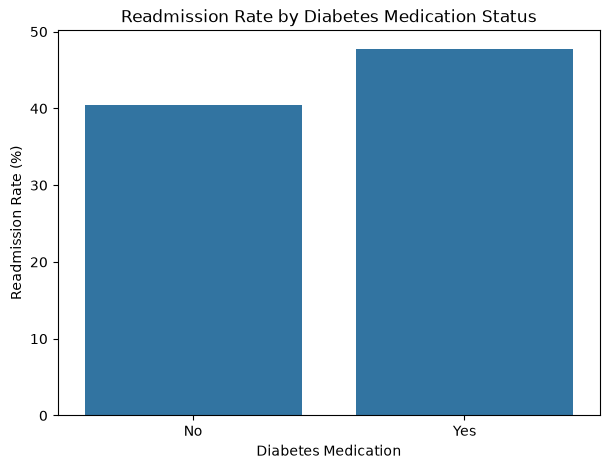

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=diabetes_med_readmission.reset_index(),
    x="diabetesMed",
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by Diabetes Medication Status"
)

plt.xlabel(
    "Diabetes Medication"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [36]:
insulin_readmission = (
    df.groupby("insulin")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

insulin_readmission["readmission_rate"] = (
    insulin_readmission["readmission_rate"] * 100
)

insulin_readmission

,total_encounters,readmissions,readmission_rate
insulin,,,
Down,12218,6450,52.790964
No,47383,20705,43.697107
Steady,30849,13915,45.106811
Up,11316,5832,51.537646


In [37]:
a1c_readmission = (
    df.groupby("A1Cresult_available")["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

a1c_readmission["readmission_rate"] = (
    a1c_readmission["readmission_rate"] * 100
)

a1c_readmission

,total_encounters,readmissions,readmission_rate
A1Cresult_available,,,
0,84748,39426,46.521452
1,17018,7476,43.929957


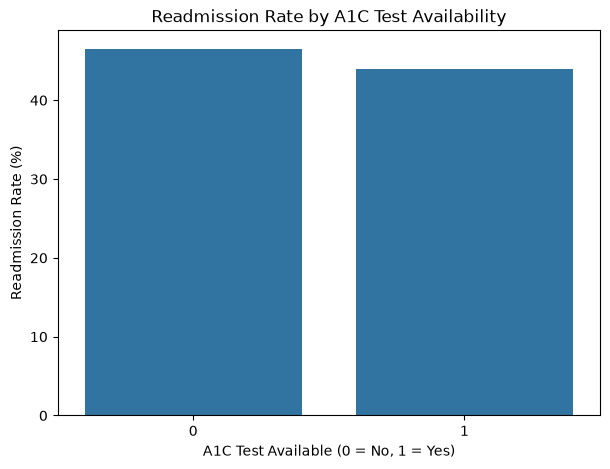

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=a1c_readmission.reset_index(),
    x="A1Cresult_available",
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by A1C Test Availability"
)

plt.xlabel(
    "A1C Test Available (0 = No, 1 = Yes)"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [39]:
glucose_readmission = (
    df.groupby(
        "max_glu_serum_available"
    )["readmitted"]
    .agg(
        total_encounters="count",
        readmissions="sum",
        readmission_rate="mean"
    )
)

glucose_readmission["readmission_rate"] = (
    glucose_readmission["readmission_rate"] * 100
)

glucose_readmission

,total_encounters,readmissions,readmission_rate
max_glu_serum_available,,,
0,96420,44305,45.950010
1,5346,2597,48.578376


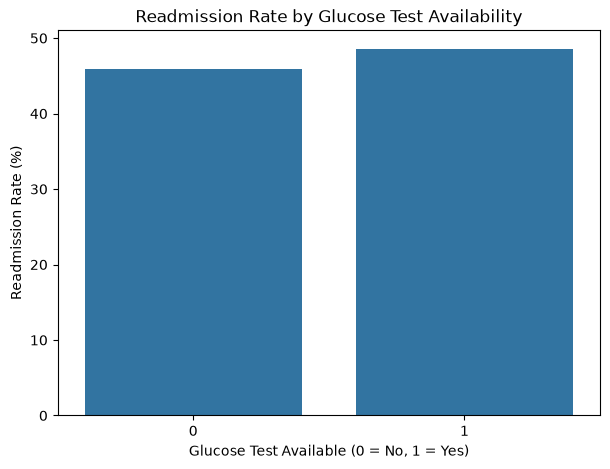

In [40]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=glucose_readmission.reset_index(),
    x="max_glu_serum_available",
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by Glucose Test Availability"
)

plt.xlabel(
    "Glucose Test Available (0 = No, 1 = Yes)"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

In [41]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

In [42]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


In [43]:
feature_summary = pd.DataFrame({
    "Feature": [
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "number_diagnoses"
    ],
    "Type": [
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical"
    ],
    "Potential_Importance": [
        "High",
        "Medium",
        "Medium",
        "High",
        "High",
        "High",
        "High",
        "High"
    ]
})

feature_summary

,Feature,Type,Potential_Importance
0,time_in_hospital,Numerical,High
1,num_lab_procedures,Numerical,Medium
2,num_procedures,Numerical,Medium
3,num_medications,Numerical,High
4,number_outpatient,Numerical,High
5,number_emergency,Numerical,High
6,number_inpatient,Numerical,High
7,number_diagnoses,Numerical,High


In [44]:
demographic_features = [
    "race",
    "gender",
    "age"
]

hospital_features = [
    "time_in_hospital",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

utilization_features = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

clinical_features = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

diabetes_features = [
    "diabetesMed",
    "insulin",
    "A1Cresult_available",
    "max_glu_serum_available"
]

In [45]:
columns_to_exclude = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

In [46]:
EDA_DATA_PATH = (
    BASE_DIR
    / "Data"
    / "Processed"
    / "eda_ready_data.csv"
)

df.to_csv(
    EDA_DATA_PATH,
    index=False
)

print(
    f"EDA dataset saved to:\n{EDA_DATA_PATH}"
)

EDA dataset saved to:
c:\Users\Sai\Documents\HealthSense_AI\Data\Processed\eda_ready_data.csv
